<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/supervised/classification/experiment_logistic_regression_progression_basic_feature_engineering_iris_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# LEVEL 1: BASIC CLASSIFICATION (LOGISTIC REG)
# ============================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# -------------------------------
# 1. Create simple data
# -------------------------------
X = np.random.randn(1000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)

# -------------------------------
# 2. Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 3. Model
# -------------------------------
model1 = LogisticRegression()

model1.fit(X_train, y_train)

# -------------------------------
# 4. Prediction
# -------------------------------
preds = model1.predict(X_test)

accuracy_ml1 = accuracy_score(y_test, preds)

print("Level 1 Accuracy:", accuracy_ml1)

Level 1 Accuracy: 1.0


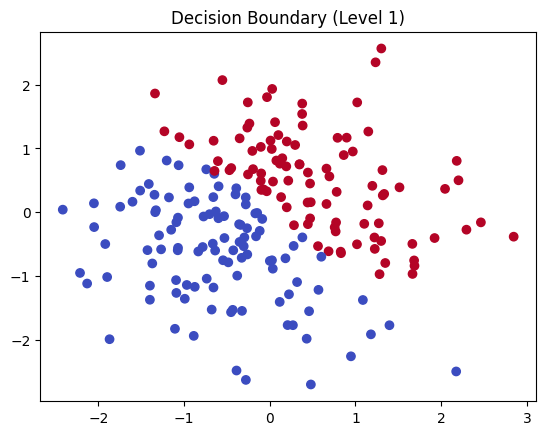

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:,0], X_test[:,1], c=preds, cmap='coolwarm')
plt.title("Decision Boundary (Level 1)")
plt.show()

In [3]:
# ============================================
# LEVEL 2: FEATURE ENGINEERING
# ============================================

# Add polynomial feature
X_new = np.c_[X, X[:,0]**2, X[:,1]**2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_new, y, test_size=0.2, random_state=42
)

model2 = LogisticRegression(max_iter=1000)

model2.fit(X_train2, y_train2)

preds2 = model2.predict(X_test2)

accuracy_ml2 = accuracy_score(y_test2, preds2)

print("Level 2 Accuracy:", accuracy_ml2)

Level 2 Accuracy: 0.99


In [4]:
# ============================================
# LEVEL 3: REAL DATA (IRIS)
# ============================================

from sklearn.datasets import load_iris

data = load_iris()

X = data.data
y = data.target

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model3 = LogisticRegression(max_iter=200)

model3.fit(X_train3, y_train3)

preds3 = model3.predict(X_test3)

accuracy_ml3 = accuracy_score(y_test3, preds3)

print("Level 3 Accuracy:", accuracy_ml3)

Level 3 Accuracy: 1.0


In [5]:
# ============================================
# LEVEL 4: PRODUCTION PIPELINE
# ============================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=200))
])

pipeline.fit(X_train3, y_train3)

preds4 = pipeline.predict(X_test3)

accuracy_ml4 = accuracy_score(y_test3, preds4)

print("Level 4 Accuracy:", accuracy_ml4)

Level 4 Accuracy: 1.0


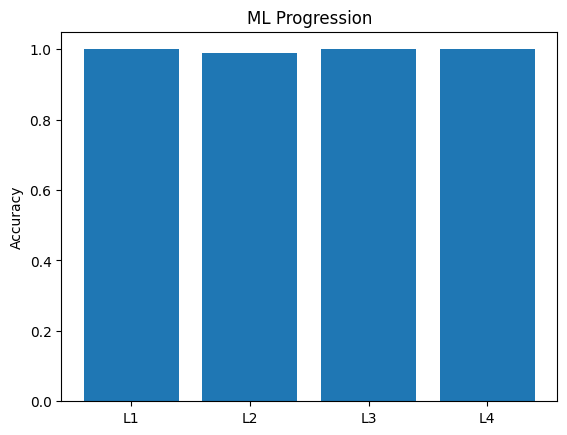

In [6]:
levels = ["L1", "L2", "L3", "L4"]
accuracies = [accuracy_ml1, accuracy_ml2, accuracy_ml3, accuracy_ml4]

import matplotlib.pyplot as plt

plt.figure()
plt.bar(levels, accuracies)
plt.title("ML Progression")
plt.ylabel("Accuracy")
plt.show()